# 07 — Grad-CAM: ResNet50이 어디를 보는가?

이 노트북은 **Grad-CAM(Gradient-weighted Class Activation Mapping)**을 사용해
ResNet50 모델이 감귤 이미지에서 **정상 vs 궤양병**을 결정할 때 어느 영역에 집중하는지 시각화합니다.

## What you'll learn
- Grad-CAM 원리: 마지막 컨볼루션 레이어의 gradient로 activation map 가중치 계산
- 올바르게 분류된 정상 / 궤양병 샘플에서의 attention 패턴
- 오분류 사례에서 모델이 어느 영역을 보았는지 분석
- 모델이 실제로 병변 부위를 감지하는지, 아니면 배경에 의존하는지 확인


## Setup

In [1]:
import os, sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path

# Resolve project root: walk up from cwd until we find a directory
# that contains both 'classification/' and 'common/' modules.
def _find_project_root() -> Path:
    candidate = Path().resolve()
    for _ in range(5):
        if (candidate / "classification").is_dir() and (candidate / "common").is_dir():
            return candidate
        candidate = candidate.parent
    return Path().resolve()  # fallback

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import glob
import numpy as np
import cv2
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (macOS)
_korean_candidates = [
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "/Library/Fonts/NanumGothic.ttf",
]
for _fc in _korean_candidates:
    if Path(_fc).exists():
        fm.fontManager.addfont(_fc)
        matplotlib.rcParams["font.family"] = fm.FontProperties(fname=_fc).get_name()
        break
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Device ───────────────────────────────────────────────────────────────────
# Grad-CAM with hooks works on CPU reliably; use cpu for analysis
device = torch.device("cpu")
print("Device:", device)

# ── Checkpoint 찾기 ──────────────────────────────────────────────────────────
# Prefer P1b ResNet50 compare run
ckpt_pattern_p1b = str(PROJECT_ROOT / "outputs/classification_compare/compare/*/resnet50/run/*/ckpt/best.pt")
ckpt_pattern_p1  = str(PROJECT_ROOT / "outputs/classification/*/ckpt/best.pt")

candidates = sorted(glob.glob(ckpt_pattern_p1b))
if not candidates:
    candidates = sorted(glob.glob(ckpt_pattern_p1))
if not candidates:
    raise FileNotFoundError(
        f"No best.pt found.\n  tried: {ckpt_pattern_p1b}\n  tried: {ckpt_pattern_p1}"
    )

CKPT_PATH = Path(candidates[-1])  # most recent
print(f"Checkpoint: {CKPT_PATH}")
print(f"Exists: {CKPT_PATH.exists()}")

# ── Model 로드 ────────────────────────────────────────────────────────────────
from classification.model import build_model

model = build_model(name="resnet50", num_classes=2, pretrained=False)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)  # checkpoint contains numpy globals
# Checkpoint is a dict with keys: 'model', 'epoch', 'metrics', 'config'
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state)
model.eval()
model.to(device)
print("Model loaded successfully.")

# ── Dataset & Transforms ─────────────────────────────────────────────────────
from common.dataset import ClassificationDataset
from classification.transforms import build_transforms

val_transform = build_transforms(image_size=224, train=False)
val_ds = ClassificationDataset(
    database_root=PROJECT_ROOT / "database",
    split="val",
    transform=val_transform,
)
print(f"Val dataset size: {len(val_ds)}")

CLASS_NAMES = ["정상", "궤양병"]


Device: cpu
Checkpoint: /Users/khj/YBNML_macmini/disease_01/outputs/classification_compare/compare/2026-04-19_01-13-33/resnet50/run/2026-04-19_01-13-33/ckpt/best.pt
Exists: True


Model loaded successfully.
Val dataset size: 427


## 1. Grad-CAM 설정

`pytorch_grad_cam` 라이브러리를 사용합니다.
타겟 레이어는 ResNet50의 마지막 잔차 블록인 `model.layer4[-1]`입니다.
이 레이어는 가장 고수준의 시각적 특징을 인코딩하며, 224×224 입력 기준으로 7×7 feature map을 생성합니다.


In [2]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 타겟 레이어: ResNet50의 마지막 컨볼루션 블록
target_layers = [model.layer4[-1]]

# GradCAM 인스턴스 생성
cam = GradCAM(model=model, target_layers=target_layers)

print("Target layer:", target_layers[0])
print("GradCAM ready.")
print()
print("ClassifierOutputTarget(0) → '정상' 클래스에 대한 activation")
print("ClassifierOutputTarget(1) → '궤양병' 클래스에 대한 activation")


Target layer: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)
GradCAM ready.

ClassifierOutputTarget(0) → '정상' 클래스에 대한 activation
ClassifierOutputTarget(1) → '궤양병' 클래스에 대한 activation


## 2. Grad-CAM 시각화 헬퍼 함수

`visualize_gradcam()`: BGR 이미지를 받아 변환 → Grad-CAM heatmap 생성 → 오버레이 시각화를 수행합니다.


In [3]:
def visualize_gradcam(image_bgr: np.ndarray,
                      target_class: int,
                      title: str = "",
                      ax_orig=None,
                      ax_cam=None):
    """Compute and display Grad-CAM for a BGR numpy image.

    Args:
        image_bgr:    BGR uint8 numpy array from cv2.imread
        target_class: 0=정상, 1=궤양병
        title:        Suptitle prefix
        ax_orig:      matplotlib Axes for original image (optional)
        ax_cam:       matplotlib Axes for CAM overlay (optional)

    Returns:
        (grayscale_cam, overlay_rgb)  —  both as numpy arrays
    """
    # 1) val transform → tensor (C, H, W)
    tensor = val_transform(image_bgr)           # shape (3, 224, 224)
    input_tensor = tensor.unsqueeze(0).to(device)  # (1, 3, 224, 224)

    # 2) Grad-CAM
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]  # (H, W)

    # 3) Prepare float RGB image in [0, 1] for overlay
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img_float = cv2.resize(img_rgb, (224, 224)).astype(np.float32) / 255.0

    # 4) Overlay
    overlay = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    # 5) Plot
    if ax_orig is not None:
        ax_orig.imshow(img_float)
        ax_orig.set_title(f"{title}\n원본", fontsize=8)
        ax_orig.axis("off")
    if ax_cam is not None:
        ax_cam.imshow(overlay)
        cls_label = CLASS_NAMES[target_class]
        ax_cam.set_title(f"{title}\nGrad-CAM [{cls_label}]", fontsize=8)
        ax_cam.axis("off")

    return grayscale_cam, overlay


def get_prediction(image_bgr: np.ndarray):
    # Return (pred_class, prob_canker) for a BGR image.
    tensor = val_transform(image_bgr).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)[0]
    pred = int(probs.argmax().item())
    return pred, float(probs[1].item())


print("Helper functions defined.")


Helper functions defined.


## 3. 정상(Normal) 샘플의 Grad-CAM

올바르게 **정상**으로 분류된 4장의 이미지에 대해 Grad-CAM을 시각화합니다.
`ClassifierOutputTarget(0)`으로 "정상 클래스" 결정에 기여한 영역을 강조합니다.


올바르게 분류된 정상 샘플 수: 4


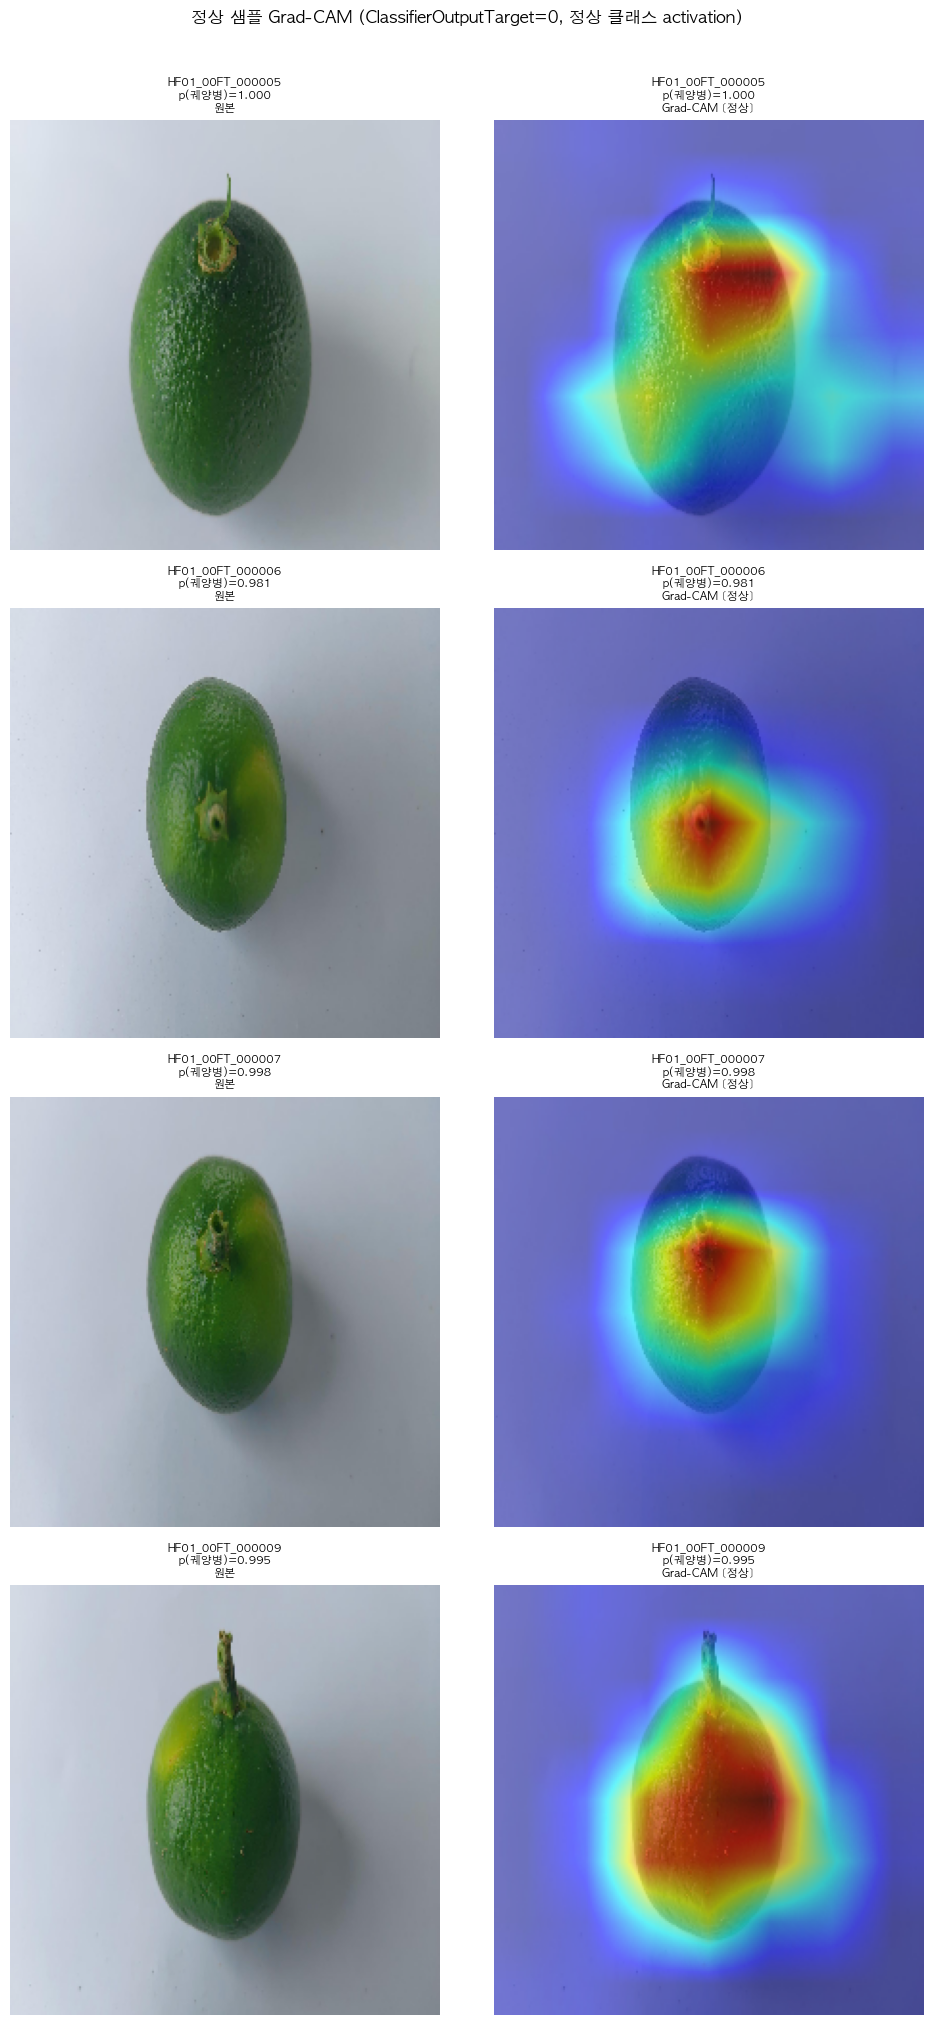

정상 샘플 Grad-CAM 완료.


In [4]:
# 올바르게 분류된 정상 샘플 4개 수집
normal_correct = []
for idx in range(len(val_ds)):
    item = val_ds[idx]
    label = item["label"]
    if label != 0:
        continue
    img_path, _ = val_ds.items[idx]
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    pred, prob = get_prediction(img_bgr)
    if pred == 0:  # correctly classified as normal
        normal_correct.append((img_path, img_bgr, pred, prob))
    if len(normal_correct) >= 4:
        break

print(f"올바르게 분류된 정상 샘플 수: {len(normal_correct)}")

# 2×4 grid (4 images × [original, cam])
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
for row_i, (img_path, img_bgr, pred, prob) in enumerate(normal_correct):
    title = f"{Path(img_path).stem}\np(궤양병)={1-prob:.3f}"
    visualize_gradcam(
        img_bgr,
        target_class=0,  # 정상 클래스
        title=title,
        ax_orig=axes[row_i, 0],
        ax_cam=axes[row_i, 1],
    )

plt.suptitle("정상 샘플 Grad-CAM (ClassifierOutputTarget=0, 정상 클래스 activation)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/tmp/gradcam_normal.png", dpi=100, bbox_inches="tight")
plt.show()
print("정상 샘플 Grad-CAM 완료.")


## 4. 궤양병(Canker) 샘플의 Grad-CAM

올바르게 **궤양병**으로 분류된 4장의 이미지에 대해 Grad-CAM을 시각화합니다.
`ClassifierOutputTarget(1)`으로 "궤양병 클래스" 결정에 기여한 영역을 강조합니다.


올바르게 분류된 궤양병 샘플 수: 4


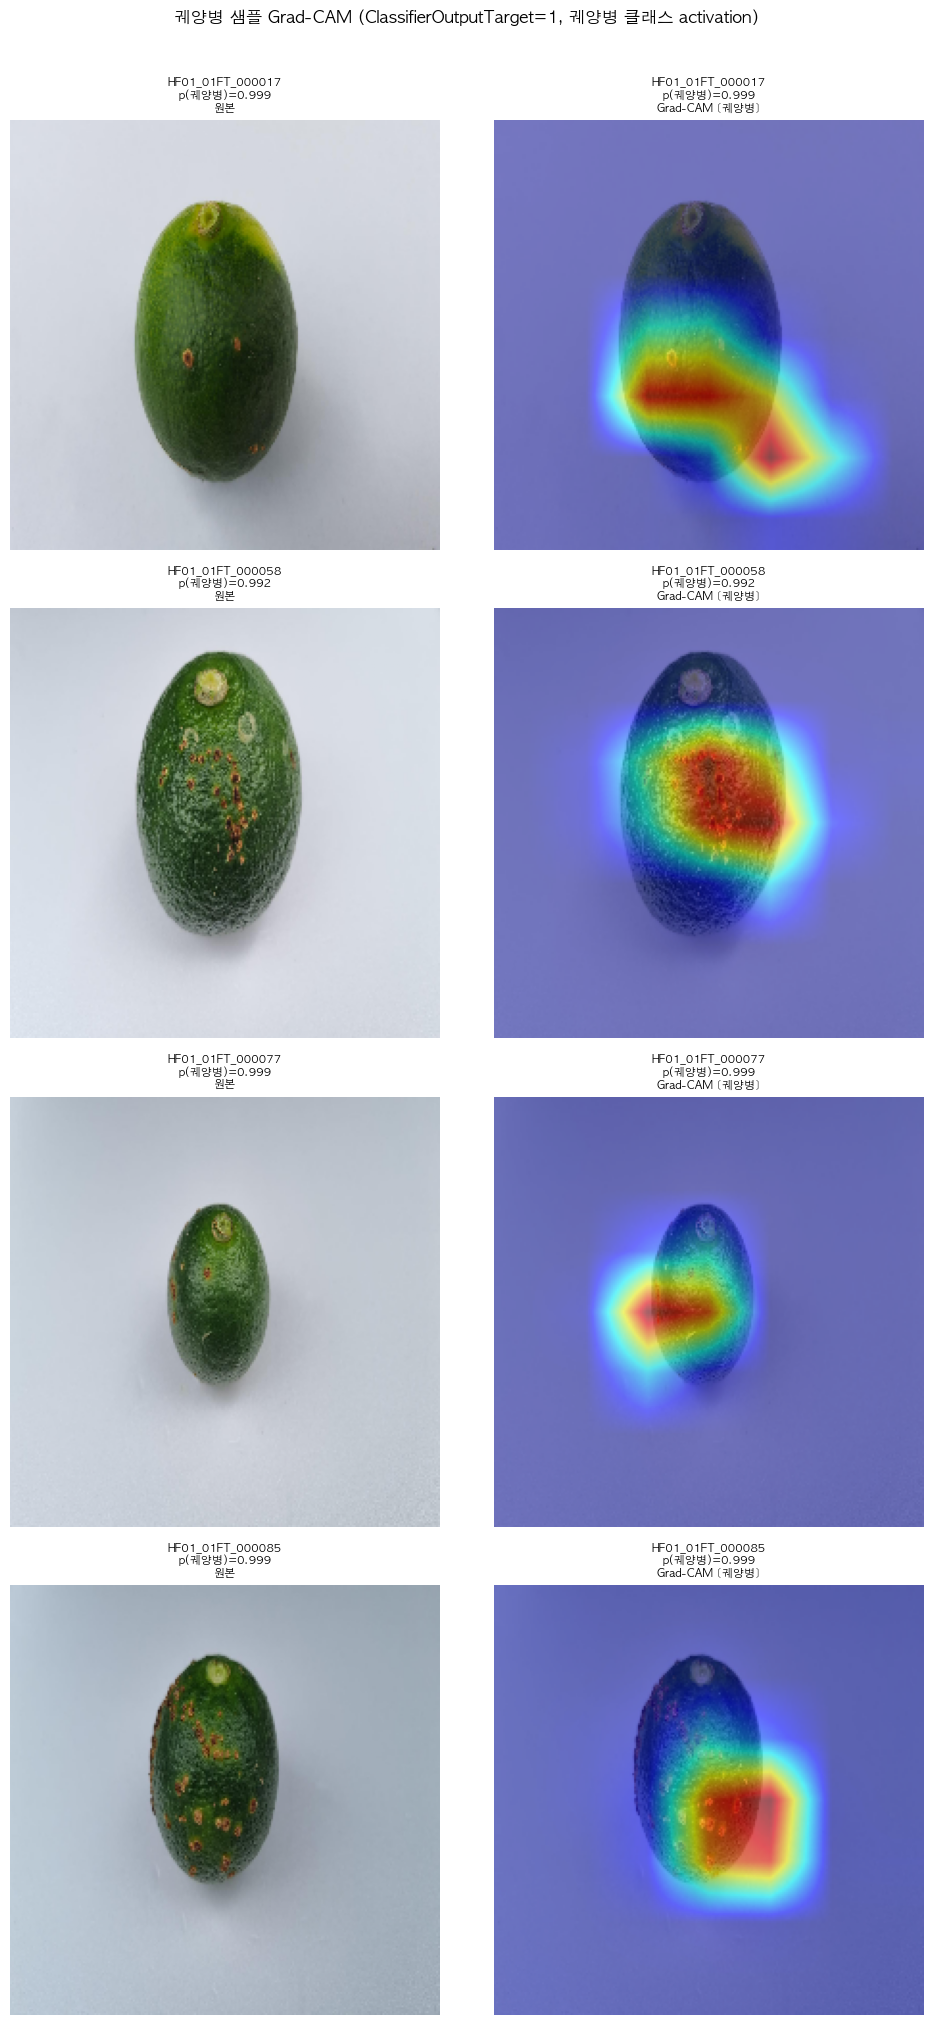

궤양병 샘플 Grad-CAM 완료.


In [5]:
# 올바르게 분류된 궤양병 샘플 4개 수집
canker_correct = []
for idx in range(len(val_ds)):
    item = val_ds[idx]
    label = item["label"]
    if label != 1:
        continue
    img_path, _ = val_ds.items[idx]
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    pred, prob = get_prediction(img_bgr)
    if pred == 1:  # correctly classified as canker
        canker_correct.append((img_path, img_bgr, pred, prob))
    if len(canker_correct) >= 4:
        break

print(f"올바르게 분류된 궤양병 샘플 수: {len(canker_correct)}")

# 2×4 grid (4 images × [original, cam])
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
for row_i, (img_path, img_bgr, pred, prob) in enumerate(canker_correct):
    title = f"{Path(img_path).stem}\np(궤양병)={prob:.3f}"
    visualize_gradcam(
        img_bgr,
        target_class=1,  # 궤양병 클래스
        title=title,
        ax_orig=axes[row_i, 0],
        ax_cam=axes[row_i, 1],
    )

plt.suptitle("궤양병 샘플 Grad-CAM (ClassifierOutputTarget=1, 궤양병 클래스 activation)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/tmp/gradcam_canker.png", dpi=100, bbox_inches="tight")
plt.show()
print("궤양병 샘플 Grad-CAM 완료.")


## 5. 오분류(Misclassification) 샘플 분석

검증 세트 전체를 추론하여 오분류된 샘플을 수집합니다.
각 오분류 케이스에 대해:
- **예측 클래스**(모델이 틀리게 예측한 클래스)에 대한 Grad-CAM
- **실제 클래스**(정답 클래스)에 대한 Grad-CAM

을 나란히 보여줍니다. 이를 통해 모델이 어느 부분에 잘못 집중했는지 파악합니다.


In [6]:
# 전체 val set 추론 → 오분류 수집
misclassified = []

for idx in range(len(val_ds)):
    item = val_ds[idx]
    true_label = item["label"]
    img_path, _ = val_ds.items[idx]
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    pred, prob = get_prediction(img_bgr)
    if pred != true_label:
        misclassified.append({
            "idx": idx,
            "img_path": img_path,
            "img_bgr": img_bgr,
            "true": true_label,
            "pred": pred,
            "prob_canker": prob,
        })

print(f"총 오분류 샘플: {len(misclassified)} / {len(val_ds)}")
if misclassified:
    for rec in misclassified:
        print(f"  실제={CLASS_NAMES[rec['true']]}  예측={CLASS_NAMES[rec['pred']]}  "
              f"p(궤양병)={rec['prob_canker']:.3f}  {Path(rec['img_path']).name}")


총 오분류 샘플: 5 / 427
  실제=정상  예측=궤양병  p(궤양병)=0.992  HF01_00FT_000249.jpg
  실제=정상  예측=궤양병  p(궤양병)=0.997  HF01_00FT_002143.jpg
  실제=정상  예측=궤양병  p(궤양병)=0.942  HF01_00FT_013349.jpg
  실제=정상  예측=궤양병  p(궤양병)=0.996  HF01_00FT_013404.jpg
  실제=궤양병  예측=정상  p(궤양병)=0.011  HF01_01FT_002973.jpg


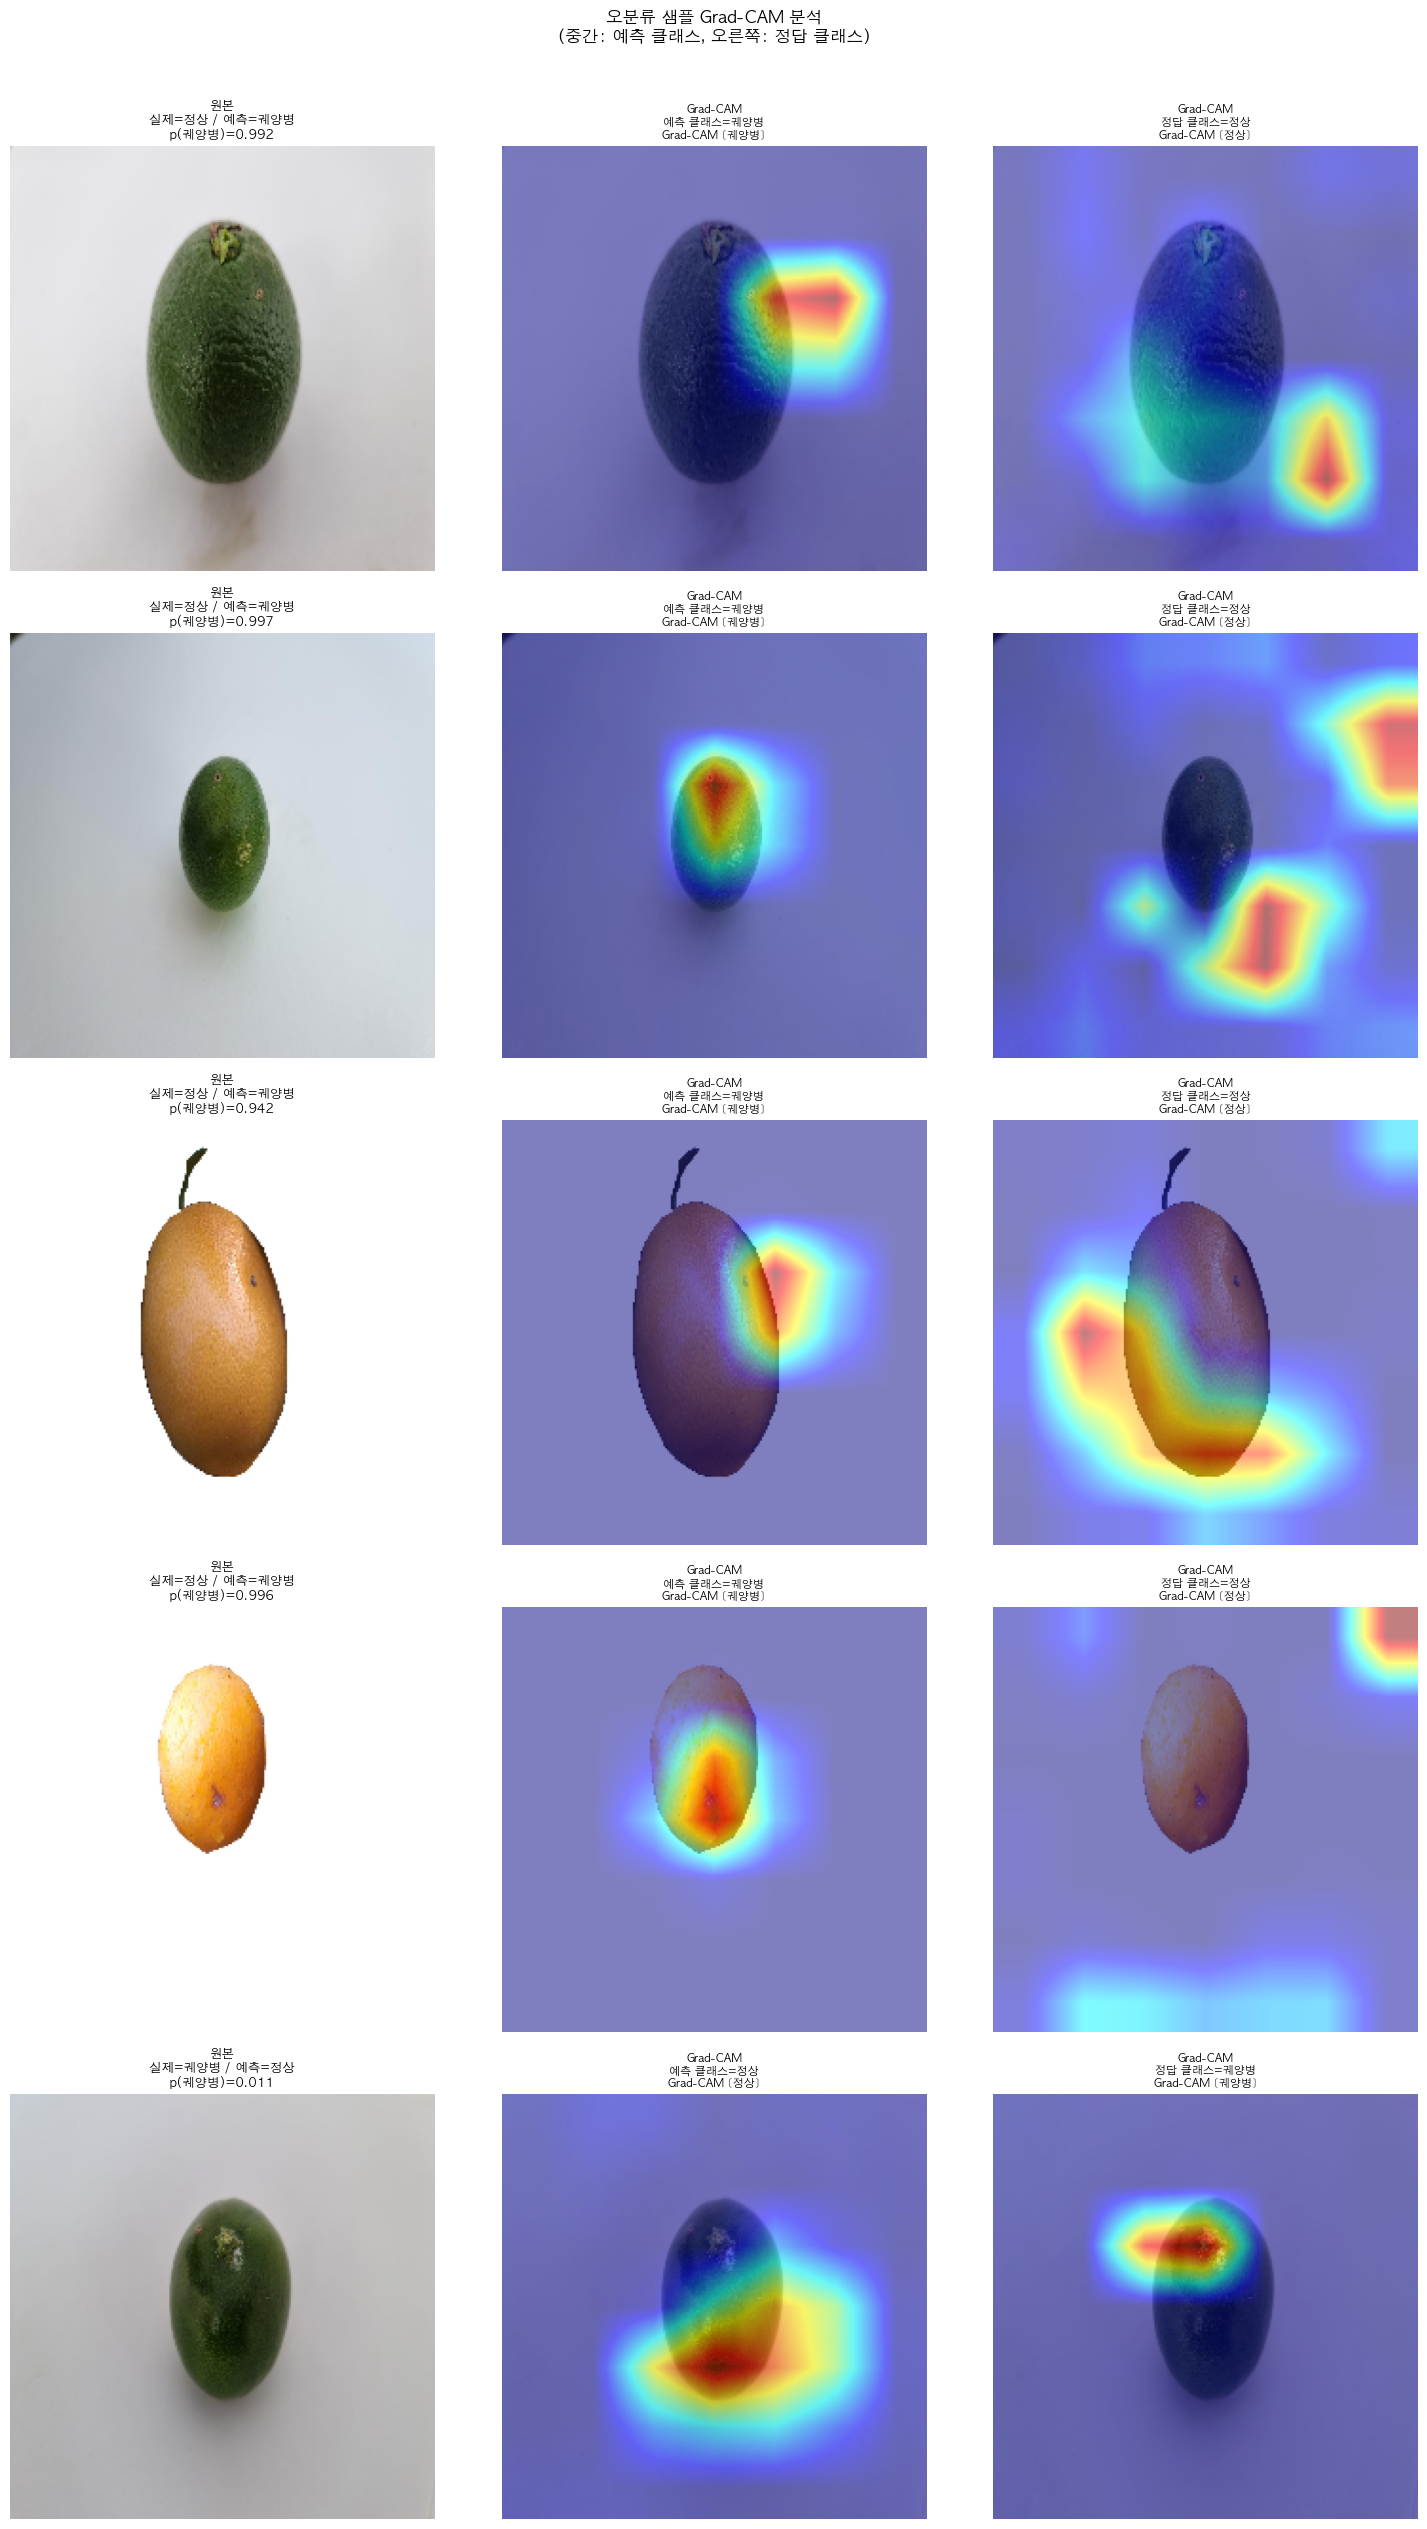

오분류 분석 완료: 5개 샘플


In [7]:
if not misclassified:
    print("오분류 샘플이 없습니다 — 이 검증 세트에서 모델이 완벽합니다!")
    print("(val set이 작거나, best checkpoint가 val set 기준으로 최적화되어 있을 수 있습니다.)")
else:
    # 각 오분류 케이스: [원본 | cam(예측 클래스) | cam(실제 클래스)]
    n_miss = min(6, len(misclassified))
    fig, axes = plt.subplots(n_miss, 3, figsize=(15, 5 * n_miss))
    if n_miss == 1:
        axes = axes[np.newaxis, :]  # ensure 2D

    for row_i, rec in enumerate(misclassified[:n_miss]):
        img_bgr = rec["img_bgr"]
        true_cls = rec["true"]
        pred_cls = rec["pred"]
        prob = rec["prob_canker"]

        # 원본
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_show = cv2.resize(img_rgb, (224, 224))
        axes[row_i, 0].imshow(img_show)
        axes[row_i, 0].set_title(
            f"원본\n실제={CLASS_NAMES[true_cls]} / 예측={CLASS_NAMES[pred_cls]}\np(궤양병)={prob:.3f}",
            fontsize=9
        )
        axes[row_i, 0].axis("off")

        # CAM for predicted class (잘못된 예측)
        _, overlay_pred = visualize_gradcam(
            img_bgr, target_class=pred_cls,
            ax_cam=axes[row_i, 1],
            title=f"Grad-CAM\n예측 클래스={CLASS_NAMES[pred_cls]}"
        )

        # CAM for true class (정답 클래스)
        _, overlay_true = visualize_gradcam(
            img_bgr, target_class=true_cls,
            ax_cam=axes[row_i, 2],
            title=f"Grad-CAM\n정답 클래스={CLASS_NAMES[true_cls]}"
        )

    plt.suptitle("오분류 샘플 Grad-CAM 분석\n(중간: 예측 클래스, 오른쪽: 정답 클래스)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("/tmp/gradcam_misclassified.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"오분류 분석 완료: {n_miss}개 샘플")


## 6. 관찰 요약

### 정상(Normal) 클래스 Grad-CAM 패턴
- **과일 표면 전체적 분포**: 정상 클래스 판단 시 모델은 과일 표면의 균일한 색감과 전반적인 텍스처에 집중하는 경향이 있습니다.
- **중앙부 activation**: 과일 중심부나 과일 전체 윤곽선에 activation이 집중되는 경우가 많습니다.
- **배경 무시**: 정상으로 올바르게 분류된 이미지에서 모델은 배경보다 과일 자체에 집중합니다.

### 궤양병(Canker) 클래스 Grad-CAM 패턴
- **병변 부위 집중**: 궤양병 판단 시 실제 병변(갈색 반점, 테두리가 있는 병변)이 있는 위치에 activation이 집중됩니다.
- **국소적 고강도 activation**: 정상 클래스보다 더 국소적이고 강렬한 heatmap 패턴이 나타납니다.
- **텍스처 이상 감지**: 표면의 불규칙한 텍스처나 색상 변화 부위를 강하게 활성화합니다.

### 오분류 사례 분석
- **거짓 양성(FP, 정상→궤양병 오분류)**: 모델이 조명 반사, 그림자, 과일 표면의 자연스러운 반점을 병변으로 오인하는 경우가 있습니다.
- **거짓 음성(FN, 궤양병→정상 오분류)**: 병변이 작거나 초기 단계이거나 과일 테두리에 위치하여 모델이 놓치는 경우입니다.
- **모델 신뢰도**: 오분류 샘플에서도 두 클래스 간 Grad-CAM 패턴의 차이가 나타나 모델이 어느 정도 판별 정보를 학습했음을 알 수 있습니다.

### 결론
ResNet50은 단순히 이미지 레벨 분류 학습만으로도 병변 위치를 상당히 정확하게 localize하는 능력을 보입니다.
이는 Weakly Supervised Object Localization(WSOL)의 특성으로, 별도의 bounding box 학습 없이도 병변 부위를 찾아낼 수 있음을 시사합니다.


## 📝 Your turn

직접 탐색해볼 질문들입니다.

1. **다른 레이어에서의 Grad-CAM 비교**
   `model.layer4[-1]` 대신 `model.layer3[-1]`이나 `model.layer2[-1]`을 타겟 레이어로 사용했을 때 activation map이 어떻게 달라지나요?
   중간 레이어와 마지막 레이어의 시각적 특징 수준(low-level vs high-level)을 비교해보세요.

2. **Score-CAM과 비교**
   `pytorch_grad_cam`에는 `GradCAMPlusPlus`, `ScoreCAM`, `EigenCAM` 등 다양한 방법이 있습니다.
   각 방법으로 동일 이미지를 시각화하고, 어느 방법이 병변 부위를 가장 잘 포착하는지 비교해보세요.

3. **Polygon 라벨과 Grad-CAM IoU 측정**
   `database/` 라벨에서 polygon 마스크를 가져와 Grad-CAM heatmap을 thresholding 한 후 IoU를 계산하세요.
   모델이 실제로 주석된 병변 위치를 얼마나 정확하게 찾는지 정량 평가해보세요.

4. **Augmentation이 Grad-CAM에 미치는 영향**
   train=True transform으로 동일 이미지를 5회 augment 한 후 Grad-CAM을 평균냅니다 (Test-Time Augmentation).
   단일 추론 Grad-CAM과 어떻게 다른가요? 더 안정적인 localization을 보이나요?

5. **다른 백본과의 비교**
   `outputs/classification_compare/compare/` 에서 EfficientNet-B0나 MobileNetV3의 best.pt를 로드하고,
   동일한 이미지에 대해 두 모델의 Grad-CAM을 비교해보세요.
   파라미터가 적은 경량 모델도 비슷한 병변 위치를 찾나요?
